In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('tashkent_residential_market_dataset_2026.csv')
df.head()

,Developer,Project Name,District,Unit Type,Size (sqm),Price,Currency
0,Murad Buildings,Nest One,Shaykhontohur,1 Bedroom,44.00,120000.0,USD
1,Murad Buildings,Nest One,Shaykhontohur,2 Bedroom,73.00,145000.0,USD
2,Independent,Modera Towers,Central,1 Bedroom,24.25,92150.0,USD
3,Golden House,Greenwich,Mirabad,2 Bedroom,56.00,114000.0,USD
4,Golden House,Greenwich,Mirabad,3 Bedroom,75.00,145000.0,USD


In [11]:
df.info()

df = df.dropna(subset=['Price', 'Size (sqm)'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Developer     35 non-null     object 
 1   Project Name  35 non-null     object 
 2   District      35 non-null     object 
 3   Unit Type     33 non-null     object 
 4   Size (sqm)    18 non-null     float64
 5   Price         33 non-null     float64
 6   Currency      33 non-null     object 
dtypes: float64(2), object(5)
memory usage: 2.0+ KB


In [12]:
df['Price_per_sqm'] = df['Price'] / df['Size (sqm)']
df['Price_per_sqm'] = round(df['Price_per_sqm'], 2)

df[['Project Name', 'District', 'Price_per_sqm']].head()

,Project Name,District,Price_per_sqm
0,Nest One,Shaykhontohur,2727.27
1,Nest One,Shaykhontohur,1986.30
2,Modera Towers,Central,3800.00
3,Greenwich,Mirabad,2035.71
4,Greenwich,Mirabad,1933.33


In [13]:
district_avg = df.groupby('District')['Price_per_sqm'].mean().reset_index()
district_avg = district_avg.sort_values(by='Price_per_sqm', ascending=False)

district_avg

,District,Price_per_sqm
6,Yunusabad,2.057886e+07
3,Olmazar,1.827676e+07
1,Mirabad,1.105415e+07
0,Central,3.800000e+03
5,Shaykhontohur,2.356785e+03
2,Mirzo-Ulugbek,1.974668e+03
4,Sergeli,4.560000e+02


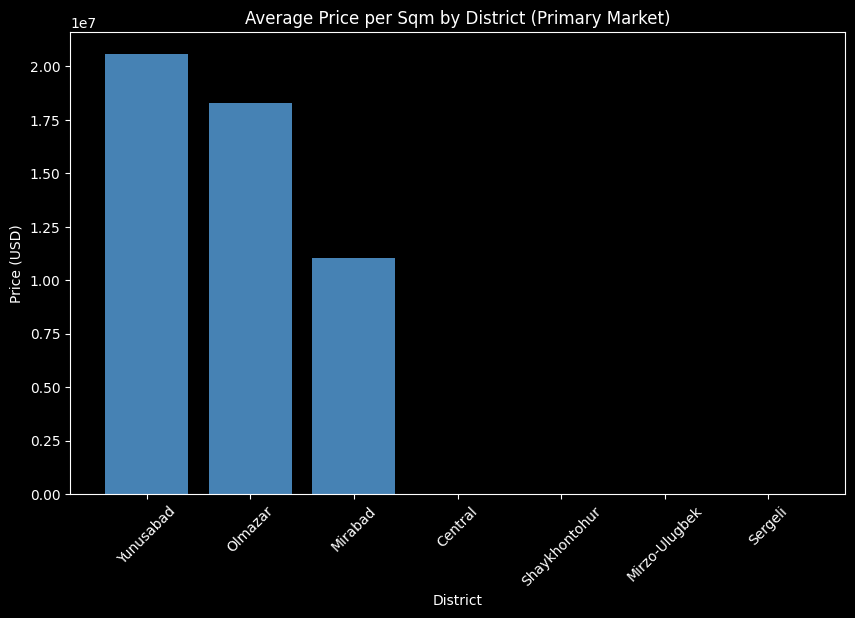

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(district_avg['District'], district_avg['Price_per_sqm'], color='steelblue')

plt.title('Average Price per Sqm by District (Primary Market)')
plt.xlabel('District')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)

plt.show()